In [2]:
import sys

sys.path.append('../src/')
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pysindy as ps
from libselection.utils import *
from libselection import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

In [8]:
data = sio.loadmat('../Data/NLS.mat')
print(data.keys())
u = data['U_exact'][...,0].item()
v = data['U_exact'][...,1].item()

x = data['x'][:,0]
t = data['t'][0]
dt = t[1]-t[0]
dx = x[2]-x[1]
print(f'Shape of u: {u.shape}, shape of x: {x.shape}, shape of t: {t.shape}, dx={dx}, dt={dt}')

dict_keys(['__header__', '__version__', '__globals__', 'U_exact', 'U_obs', 'coarsen_data', 'corners_all', 'custom_add', 'custom_remove', 'dim', 'dims', 'gamma', 'k', 'lambda', 'lhs', 'm_t', 'm_x', 'max_dt', 'max_dx', 'n', 'noise', 'noise_alg', 'noise_dist', 'p_t', 'p_x', 'pde_names', 'pde_num', 'phi_class', 'polys', 'rng_seed', 's_t', 's_x', 'sig_est', 'sigma', 'sigma_NR', 'snr', 'str', 't', 'tau', 'tauhat', 'tauhat_inds', 'toggle_scale', 'tols', 'trigs', 'true_nz_weights', 'use_all_dt', 'use_all_pt', 'use_cross_dx', 'x', 'xs', 'xs_obs'])
Shape of u: (256, 251), shape of x: (256,), shape of t: (251,), dx=0.0390625, dt=0.012566370614359173


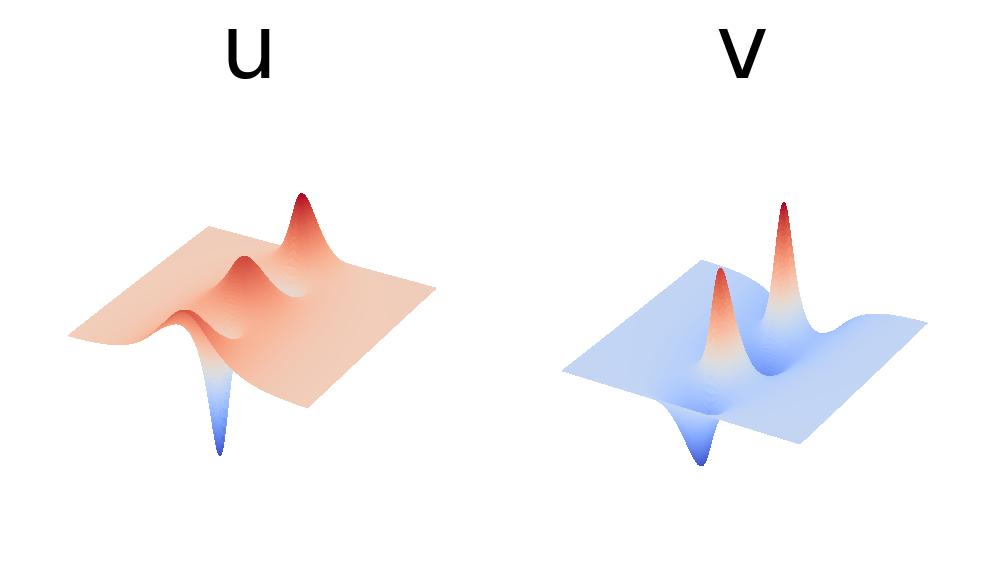

In [13]:
X, T = np.meshgrid(x, t)
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(121, projection='3d')
surf = ax.plot_surface(X, T, u.T, rstride=1, cstride=1, cmap=plt.colormaps.get('coolwarm'),
    linewidth=0, antialiased=False)
# plt.title('Burgers Equation', fontsize = 20)

ax.set_axis_off()
ax.set_title('u', fontsize=64)
# ax.set_aspect('equal')
# ax.view_init(elev=30, azim=-80)


ax = fig.add_subplot(122, projection='3d')
surf = ax.plot_surface(X, T, v.T, rstride=1, cstride=1, cmap=plt.colormaps.get('coolwarm'),
    linewidth=0, antialiased=False)
# plt.title('Burgers Equation', fontsize = 20)

ax.set_axis_off()
ax.set_title('v', fontsize=64)
# ax.set_aspect('equal')
# ax.view_init(elev=30, azim=-80)



fig.tight_layout()
fig.savefig('Figs/nls_equation_example.png', dpi=1200, format='png', bbox_inches='tight')
